# MEASURING HATE SPEECH

## 1. Introduzione

## 2. Setup & EDA 

### 2.0. - Setup della Setup

In [21]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

REPO_NAME = "measuring-hate-speech-audit"
REPO_URL  = "https://github.com/AndreaMorbello/measuring-hate-speech-audit.git"
MARKER    = Path("src") / "data.py"  # file presente solo nel repo

def _find_repo_root() -> Path:
    """Risale l'albero delle directory finché trova src/data.py."""
    for d in [Path.cwd(), *Path.cwd().parents]:
        if (d / MARKER).exists():
            return d
    raise RuntimeError(f"Repo root non trovato: nessun '{MARKER}' nelle dir parent.")

if IN_COLAB:
    if not Path(REPO_NAME).exists():
        !git clone {REPO_URL}
    # opzionale: installa dipendenze se non sei sicuro siano presenti su Colab
    # !pip install -q -r {REPO_NAME}/requirements.txt
    PROJECT_ROOT = Path(REPO_NAME).resolve()
else:
    PROJECT_ROOT = _find_repo_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Ambiente: {'Colab' if IN_COLAB else 'Locale'}")
print(f"Repo root: {PROJECT_ROOT}")

Ambiente: Locale
Repo root: c:\Users\LENOVO\Documents\dev\measuring-hate-speech-audit


### 2.1. - Importazione librerie e setup generale


Oltre agli import fondamentali, vengono inizializzate le costanti che saranno utili per l'importazione del dataset e per l'Explorative Data Analysis.

In [22]:
import sys
import subprocess
from pathlib import Path
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data import (
    get_column_groups,
    summarize_dataset,
    HF_DATASET_NAME,
    HF_CONFIG,
    platform_distribution,
    label_correlation_matrix,
    annotator_productivity, 
    comment_score_dispersion,
)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### 2.2. Caricamento del dataset

Caricamento del dataset come DataFrame e creazione di una copia da mantenersi RAW.

In [23]:
df: pd.DataFrame = load_dataset(HF_DATASET_NAME, HF_CONFIG)["train"].to_pandas()
df_raw: pd.DataFrame = df.copy()

df.head(5)

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,annotator_religion_hindu,annotator_religion_jewish,annotator_religion_mormon,annotator_religion_muslim,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other
0,47777,10873,3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
1,39773,2790,2,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
2,47101,3379,3,4.0,4.0,4.0,4.0,4.0,4.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,43625,7365,3,2.0,3.0,2.0,1.0,2.0,0.0,0.0,...,False,False,False,False,False,False,False,False,True,False
4,12538,488,0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,True,False


#

### 2.3. - Categorizzazione delle colonne

Le 143 colonne del dataset non sono epistemologicamente equivalenti: alcune identificano direttamente individui, altre descrivono caratteristiche demografiche degli annotatori, altre ancora qualificano i bersagli del discorso annotato. Un audit etico richiede di esplicitare questa stratificazione prima di qualsiasi analisi.

Seguendo la struttura del paper originale (Kennedy et al. 2020) e le categorie del GDPR, raggruppiamo le colonne in otto classi distinte:

- **Identificatori diretti** (`comment_id`, `annotator_id`): puntano in modo univoco a record e individui. Saranno pseudo-anonimizzati nel Cap. 3.
- **Testo** (`text`): il contenuto annotato, oggetto del compito di classificazione.
- **Metadata** (`platform`): contesto neutro di provenienza del commento (Instagram, Reddit, Twitter...).
- **Outcome variables**: dieci etichette ordinali (sentiment, respect, insult, humiliate, status, dehumanize, violence, genocide, attack_defend, hatespeech) più lo score continuo `hate_speech_score`, target del modello in Cap. 5.
- **Annotation quality metrics**: parametri diagnostici del modello psicometrico Rasch usato per costruire `hate_speech_score`, tra cui `annotator_severity` e l'item parameter `hypothesis`.
- **Target groups**: 76 colonne che codificano i gruppi protetti bersaglio del commento (razza, religione, origine, genere, sessualità, età, disabilità, orientamento politico), oggetto dell'analisi di bias del dataset (Cap. 4) e di fairness del modello (Cap. 6).
- **Annotator quasi-identifiers (summary)**: sei colonne categoriche sui demografici degli annotatori (genere, identità trans, istruzione, reddito, ideologia, età). **Sono il materiale operativo del Cap. 3**: l'esercizio di k-anonymity ed l-diversity si applica a queste.
- **Annotator quasi-identifiers (dummies)**: le stesse informazioni demografiche in forma binaria one-hot, utili come feature in fase di modellazione (Cap. 5) ma ridondanti per l'audit privacy.

Questa categorizzazione orienta l'intera pipeline. Ogni capitolo successivo opera su uno o due sottoinsiemi specifici, esplicitando di volta in volta quale gruppo è in gioco e perché.

In [24]:
column_groups: dict = get_column_groups(df)


for group_name, columns in column_groups.items():
    print(f"{group_name:25s}  {len(columns):3d} colonne")

direct_identifiers           2 colonne
text                         1 colonne
metadata                     1 colonne
outcomes                    11 colonne
annotation_quality           7 colonne
target_groups               65 colonne
annotator_qi_summary         6 colonne
annotator_qi_dummies        50 colonne
other                        0 colonne


### 2.4. - Statistiche descrittive di base

Prima di qualsiasi analisi mirata, fissiamo le quattro grandezze strutturali del dataset: numero di righe (= annotazioni totali), numero di commenti distinti, numero di annotatori distinti, e la distribuzione delle annotazioni per commento.

Il rapporto annotazioni/commenti è cruciale: ogni commento è giudicato da più persone e l'`hate_speech_score` è una **stima IRT aggregata** di più valutazioni soggettive, non una ground truth. Capire questa ridondanza è precondizione per ogni discussione su affidabilità delle label e fairness del modello.

In [25]:
stats: dict = summarize_dataset(df)

print(f"Righe (annotazioni totali):     {stats['n_rows']:>8,}")
print(f"Colonne:                        {stats['n_columns']:>8,}")
print(f"Commenti unici:                 {stats['n_unique_comments']:>8,}")
print(f"Annotatori unici:               {stats['n_unique_annotators']:>8,}")
print()
print(f"Annotazioni per commento (media):   {stats['annotations_per_comment_mean']:.2f}")
print(f"Annotazioni per commento (mediana): {stats['annotations_per_comment_median']:.2f}")

Righe (annotazioni totali):      135,556
Colonne:                             143
Commenti unici:                   39,565
Annotatori unici:                  7,912

Annotazioni per commento (media):   3.43
Annotazioni per commento (mediana): 2.00


### 2.4-bis. - Distribuzione per piattaforma

La colonna `platform` codifica la fonte del commento: YouTube, Reddit, Twitter (Kennedy et al. 2020). Non e' un attributo sensibile ai sensi dell'Art. 9 GDPR ne' un quasi-identificatore degli annotatori; rientra nella categoria dei metadata di contesto.

Cio' non lo rende analiticamente innocuo. Ogni piattaforma applica norme del discorso e politiche di moderazione differenti, e attira basi utenti con composizioni demografiche e ideologiche distinte. La piattaforma agisce quindi come **proxy strutturale** di una serie di variabili non osservate: convenzioni espressive, vincoli di lunghezza, attese di anonimato, soglie di tolleranza editoriale.

La distribuzione qui descritta ha valore puramente strutturale: serve a documentare il *frame* del corpus, non a derivarne conclusioni di fairness.

**Hook etico**: `platform` e' un **confounder potenziale** per ogni analisi del §3 che condizioni la performance del modello su un gruppo target. Una disparita' apparente per `target_race_black` potrebbe in realta' riflettere una sovra-rappresentazione di un sottogruppo su una specifica piattaforma, dove le norme del discorso amplificano determinati registri retorici. Il §3 tornera' su questo punto stratificando i confronti.


             count    pct
Reddit       43227  31.89
YouTube      37164  27.42
Twitter      35027  25.84
unknown (3)  20138  14.86


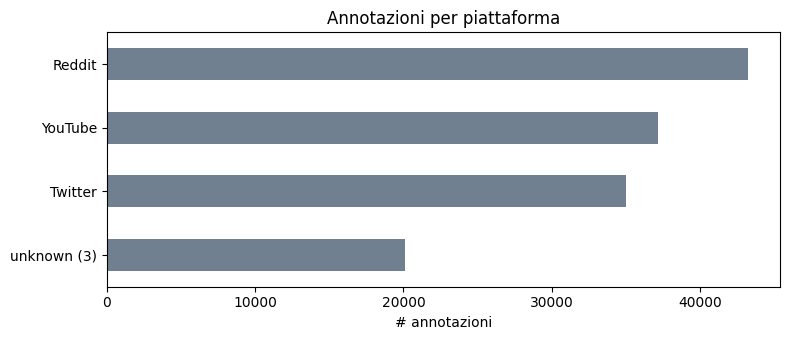

In [26]:
platform_table = platform_distribution(df)
print(platform_table.to_string(float_format=lambda x: f"{x:6.2f}"))

fig, ax = plt.subplots(figsize=(8, 3.5))
platform_table["count"].sort_values().plot(kind="barh", ax=ax, color="slategray")
ax.set_title("Annotazioni per piattaforma")
ax.set_xlabel("# annotazioni")
ax.set_ylabel("")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_platform_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.5. - Distribuzione dell'outcome continuo

`hate_speech_score` e' la variabile dipendente principale: un punteggio continuo (tipicamente nell'intervallo [-4, +4]) ottenuto via modello Rasch a partire dalle 10 etichette ordinali. Valori positivi crescenti indicano contenuto piu' hateful, valori negativi indicano contenuto sempre piu' supportivo.

L'affianco istogramma + boxplot esplicita due letture complementari della stessa distribuzione. L'istogramma rivela la forma (modalita', code, asimmetria); il boxplot riassume la geometria robusta — mediana, IQR (intervallo interquartile), baffi e outlier (Rosati, dispense Analisi Dati slide 22-23). La distanza tra mediana e media segnala l'asimmetria; la lunghezza dei baffi e la densita' degli outlier oltre 1.5*IQR misurano il peso delle code, decisivo nelle scelte di soglia.

**Hook etico**: lo score e' continuo. Qualsiasi classificatore binario (hate / non-hate) richiedera' la scelta di una soglia arbitraria, scelta che influenza direttamente i tassi di falsi positivi e negativi *e che si distribuira' in modo asimmetrico tra i gruppi target* — e' quindi una decisione di fairness, non solo tecnica.

A complemento delle statistiche aggregate, riportiamo anche i **due commenti agli estremi** dello score — il piu' hateful e il piu' supportivo del corpus. L'ispezione qualitativa serve due scopi:

1. Validare che lo score IRT cattura effettivamente cio' che ci aspettiamo (face validity).
2. Rendere visibile la natura concreta del materiale annotato. **Avvertenza**: il commento estremo positivo conterra' linguaggio hateful esplicito — e' parte ineliminabile del dominio di studio.


Statistiche di hate_speech_score:
  mean   -0.5674
  std    +2.3800
  min    -8.3400
  max    +6.3000
  q25    -2.3300
  q75    +1.4100


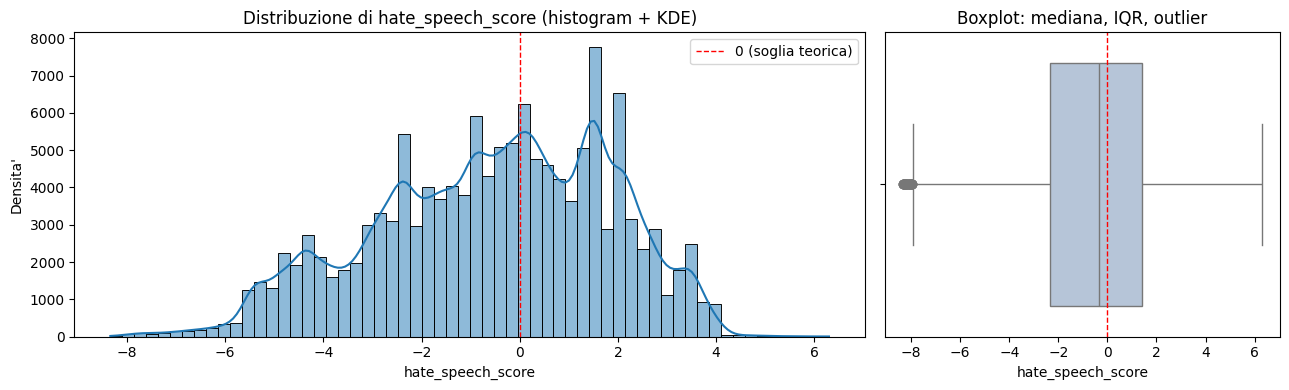


COMMENTO PIU' HATEFUL  (score = +6.3000, comment_id = 42821)
Dig burn PITS and treat them THE INVADING NAZIS ALL OVER EUROPE. ESPECIALLY THE WOMEN DON'T LET THEM BREED HERE MR. PRESIDENT. FIRING SQUADS SO I CAN VOLUNTEER

COMMENTO PIU' SUPPORTIVO  (score = -8.3400, comment_id = 5360)
Fellow trans girl here! Love and support confirmed!


In [27]:
hs_stats = stats["hate_speech_score_stats"]
print("Statistiche di hate_speech_score:")
for k, v in hs_stats.items():
    print(f"  {k:6s} {v:+.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})

sns.histplot(df["hate_speech_score"], bins=60, kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--", linewidth=1, label="0 (soglia teorica)")
axes[0].set_title("Distribuzione di hate_speech_score (histogram + KDE)")
axes[0].set_xlabel("hate_speech_score")
axes[0].set_ylabel("Densita'")
axes[0].legend()

sns.boxplot(x=df["hate_speech_score"], ax=axes[1], color="lightsteelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Boxplot: mediana, IQR, outlier")
axes[1].set_xlabel("hate_speech_score")

plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_hate_speech_score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


# --- Ispezione qualitativa: i due estremi dello score ---
# `hate_speech_score` puo' variare anche per uno stesso commento perche'
# riflette le risposte di un singolo annotatore. Per gli estremi globali
# ci basta cercare il max/min su tutte le righe.
unique_comments = df.drop_duplicates(subset="comment_id")[
    ["comment_id", "hate_speech_score", "text"]
]

most_hateful = unique_comments.loc[unique_comments["hate_speech_score"].idxmax()]
most_supportive = unique_comments.loc[unique_comments["hate_speech_score"].idxmin()]

print("\n" + "=" * 70)
print(
    f"COMMENTO PIU' HATEFUL  (score = {most_hateful['hate_speech_score']:+.4f}, "
    f"comment_id = {most_hateful['comment_id']})"
)
print("=" * 70)
print(most_hateful["text"])

print("\n" + "=" * 70)
print(
    f"COMMENTO PIU' SUPPORTIVO  (score = {most_supportive['hate_speech_score']:+.4f}, "
    f"comment_id = {most_supportive['comment_id']})"
)
print("=" * 70)
print(most_supportive["text"])

### 2.6.1. - Distribuzione delle 10 etichette ordinali

Le dieci etichette su scala Likert (0–4) sono le componenti elementari da cui Kennedy et al. derivano `hate_speech_score`. Vederne la distribuzione individualmente serve a:

1. Identificare etichette gravemente sbilanciate (es. `genocide` plausibilmente quasi sempre = 0): qualsiasi modello supervisionato su di esse rischia accuracy alta ma F1 molto bassa per la classe positiva.
2. Capire quali dimensioni di "hatefulness" il dataset misura bene e quali no.

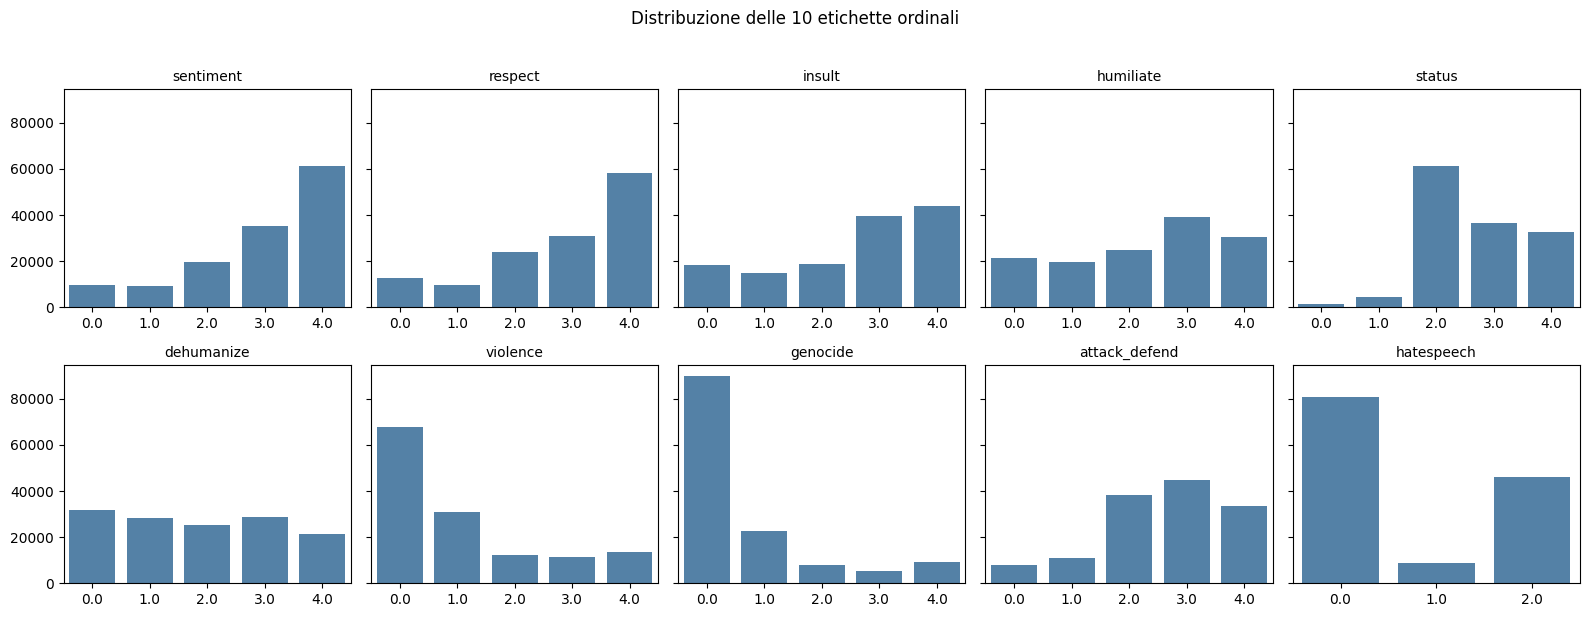

In [28]:
ordinal_labels = [c for c in column_groups["outcomes"] if c != "hate_speech_score"]

fig, axes = plt.subplots(2, 5, figsize=(16, 6), sharey=True)
for ax, label in zip(axes.flat, ordinal_labels):
    sns.countplot(x=df[label], ax=ax, color="steelblue")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Distribuzione delle 10 etichette ordinali", y=1.02)
plt.tight_layout()
plt.show()

### 2.6.2. - Correlazione tra etichette ordinali
Il modello Rasch usato in Kennedy et al. (2020) per derivare `hate_speech_score` presuppone l'esistenza di un costrutto latente **unidimensionale** che chiamiamo "hatefulness": le dieci etichette sarebbero allora altrettante manifestazioni osservabili dello stesso tratto sottostante. La heatmap di correlazione di Spearman e' lo strumento empirico minimo per stressare questa assunzione.

La scelta di Spearman e non di Pearson e' obbligata: le etichette sono ordinali (scala Likert 0-4), non a intervallo. Spearman misura l'associazione monotonica tra ranghi, senza assumere linearita' ne' distribuzione normale (Rosati, dispense Analisi Dati slide 65-67).

Cosa aspettarsi se l'ipotesi di unidimensionalita' regge: blocchi consistenti di correlazioni positive forti tra etichette semanticamente affini (`insult`, `dehumanize`, `humiliate`) e correlazioni negative significative tra `respect` e il resto. Lo scarto da questo pattern atteso e' diagnostico: ogni etichetta con correlazione bassa o erratica con il resto segnala che misura una dimensione semi-autonoma di "hatefulness", non riducibile al continuum aggregato.

**Hook etico**: se etichette estreme come `genocide` o `violence` mostrano correlazioni basse con il resto, l'aggregazione in un singolo `hate_speech_score` continuo **occulta dimensioni etiche eterogenee**. Un commento marcato come incitamento al genocidio e uno percepito come "insultante ma non violento" possono ricevere punteggi compositi simili pur essendo qualitativamente incomparabili. Il problema diventa centrale al §5: spiegare lo score di un classificatore costruito su un costrutto eterogeneo richiede di esplicitare *quale* dimensione di hatefulness sta guidando la singola predizione, pena un'interpretabilita' falsa.


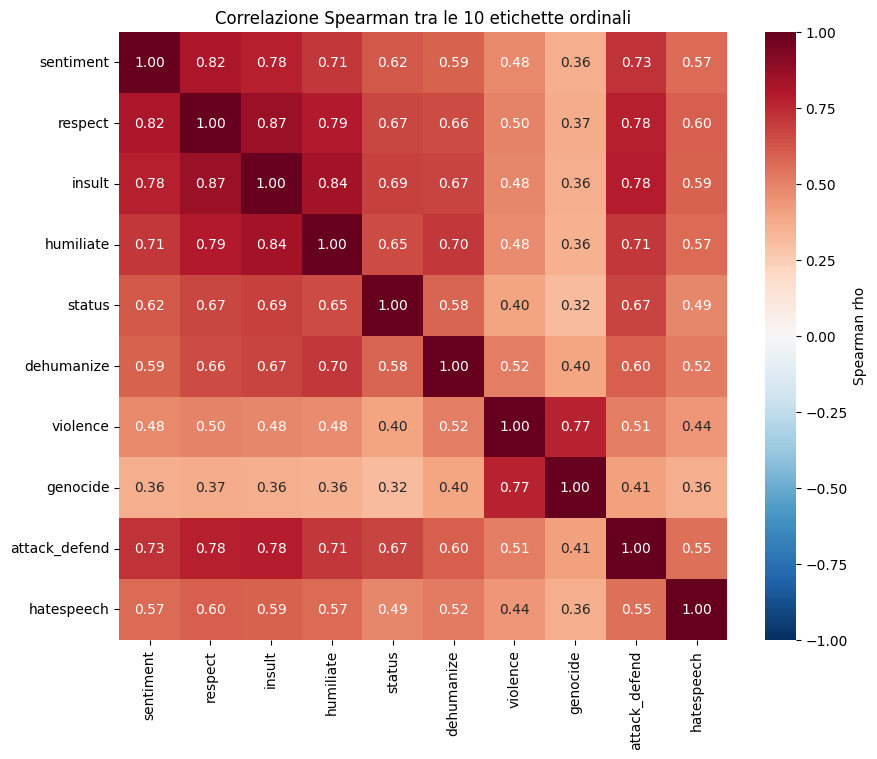

In [29]:
corr_matrix = label_correlation_matrix(df)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Spearman rho"},
    ax=ax,
)
ax.set_title("Correlazione Spearman tra le 10 etichette ordinali")
plt.tight_layout()

fig.savefig(FIGURES_DIR / "eda_label_correlation_spearman.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.7.1. - Demografia degli annotatori

Analizziamo la composizione del pool di annotatori sulle sei dimensioni summary identificate al §2.3: genere, identità trans, istruzione, reddito, ideologia politica, età.

**Attenzione metodologica**: il df è organizzato per annotazione, non per annotatore — un singolo annotatore appare in N righe (una per ciascun commento giudicato). Per la statistica demografica dobbiamo **deduplicare per `annotator_id`**, altrimenti gli annotatori più produttivi pesano sproporzionatamente.

**Hook etico**: questa composizione è la lente attraverso cui il dataset "vede" l'hate speech. Sbilanciamenti sistematici (es. ideologia fortemente polarizzata, sottorappresentazione di gruppi specifici) si traducono in bias delle label che il modello assorbirà silenziosamente. È il punto di partenza obbligato per il §3 (Fairness).

Annotatori unici nel pool: 7,912


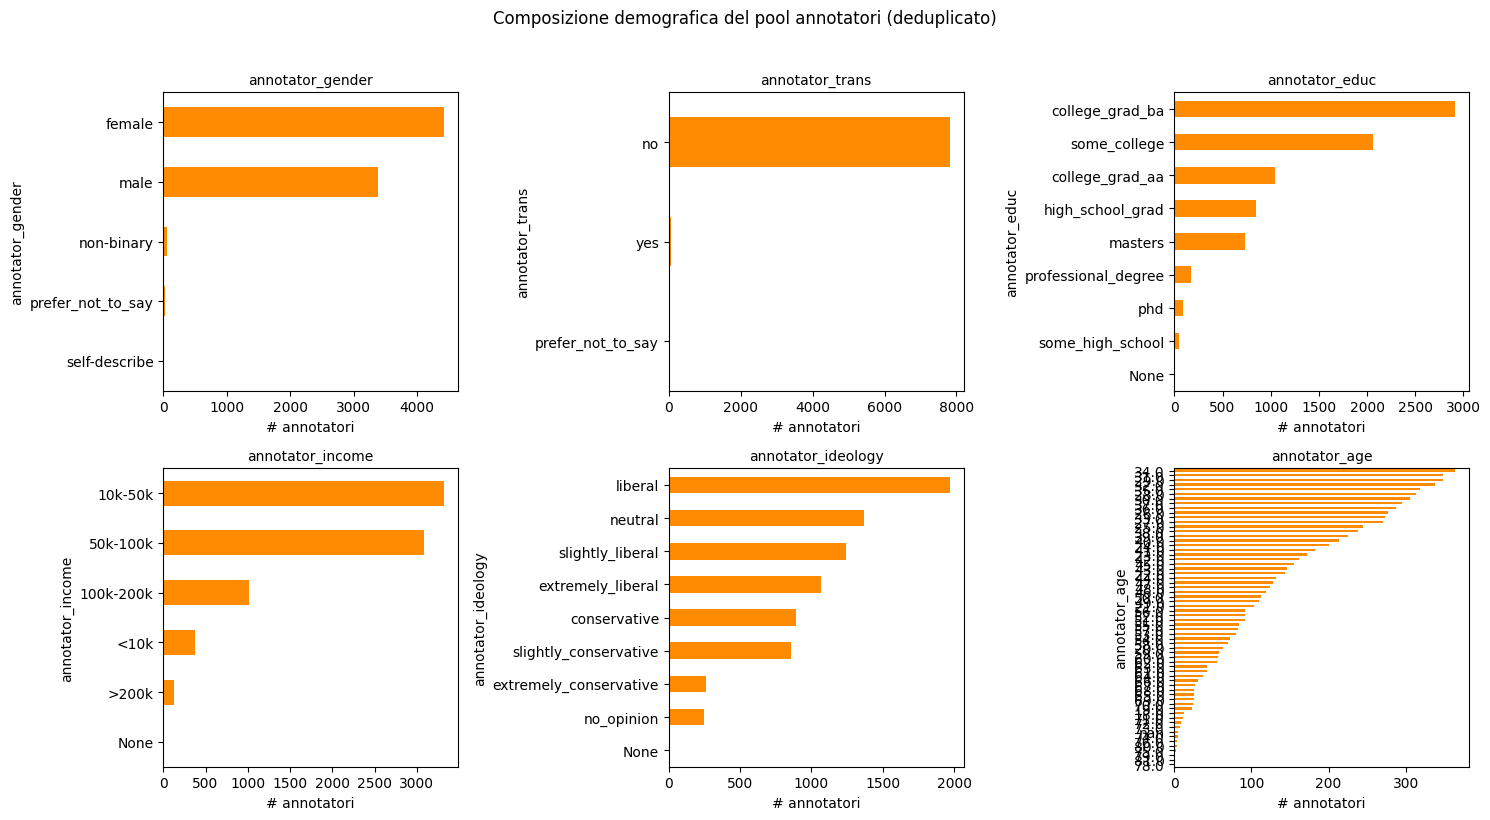

In [30]:
annotators = df.drop_duplicates(subset="annotator_id")
print(f"Annotatori unici nel pool: {len(annotators):,}")

summary_cols = column_groups["annotator_qi_summary"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, summary_cols):
    counts = annotators[col].value_counts(dropna=False)
    counts.plot(kind="barh", ax=ax, color="darkorange")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("# annotatori")
    ax.invert_yaxis()
fig.suptitle("Composizione demografica del pool annotatori (deduplicato)", y=1.02)
plt.tight_layout()
plt.show()

### 2.7.2. - Affidabilita' delle annotazioni

Due diagnostiche complementari quantificano la solidita' del processo di annotazione: la **distribuzione della produttivita' tra annotatori** e la **dispersione intra-commento** dei punteggi.

(a) *Concentrazione della produttivita'*. Il pool annotatori non e' omogeneo per impegno. Mostriamo l'istogramma del numero di annotazioni per persona e calcoliamo l'indice di Gini sulla distribuzione (implementazione manuale, formula chiusa). Un Gini vicino a 0 segnala carico uniforme; valori oltre 0.5 indicano una minoranza produttiva che produce la maggior parte delle etichette.

(b) *Disaccordo intra-commento*. Per ogni commento con almeno due annotatori calcoliamo la deviazione standard di `hate_speech_score` e ne mostriamo la distribuzione. Std bassa = consenso (commento "pacificamente" hateful o non-hateful); std alta = commento controverso, dove gli annotatori divergono nella stessa scala. Commenti con un solo annotatore producono NaN e sono esclusi.

**Hook etico**: il primo grafico mette in discussione l'idea stessa di "consenso del pool". Se l'1% piu' produttivo degli annotatori produce una quota sproporzionata di etichette, il modello del §5 imparera' a riprodurre il consenso di una minoranza, non del pool dichiarato. Il secondo grafico distingue i commenti dove la nozione di hate speech e' contestata da quelli dove e' condivisa: e' precisamente sui commenti controversi che il §3 dovra' valutare il comportamento del modello, perche' la' la decisione di soglia ha conseguenze etiche massime.

*Nota tecnica*: una misura di accordo inter-rater piu' rigorosa come Krippendorff alpha richiederebbe gestire il design di annotazione parzialmente sovrapposto e aggiungere una dipendenza esterna (`krippendorff` o `simpledorff`). Rimandata a iterazione futura.


Annotazioni per annotatore  --  media: 17.13, mediana: 17.00, max: 26
Indice di Gini: 0.1265
Quota di annotazioni prodotta dall'1% piu' produttivo: 1.5%

Commenti con >= 2 annotatori: 29,488
Std intra-commento  --  mediana: 0.000, media: 0.000, max: 0.000


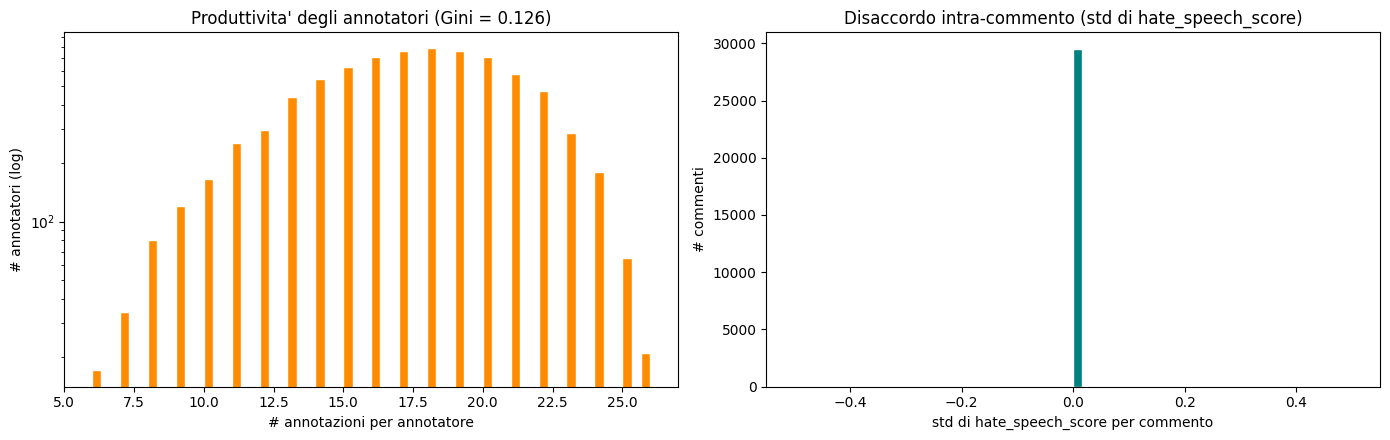

In [31]:
prod = annotator_productivity(df)

print(
    f"Annotazioni per annotatore  --  media: {prod['mean']:.2f}, "
    f"mediana: {prod['median']:.2f}, max: {prod['max']}"
)
print(f"Indice di Gini: {prod['gini']:.4f}")
print(
    f"Quota di annotazioni prodotta dall'1% piu' produttivo: " f"{prod['top1pct_share'] * 100:.1f}%"
)

dispersion = comment_score_dispersion(df)
print(f"\nCommenti con >= 2 annotatori: {len(dispersion):,}")
print(
    f"Std intra-commento  --  mediana: {dispersion.median():.3f}, "
    f"media: {dispersion.mean():.3f}, max: {dispersion.max():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(prod["counts"].values, bins=60, color="darkorange", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title(f"Produttivita' degli annotatori (Gini = {prod['gini']:.3f})")
axes[0].set_xlabel("# annotazioni per annotatore")
axes[0].set_ylabel("# annotatori (log)")

axes[1].hist(dispersion.values, bins=60, color="teal", edgecolor="white")
axes[1].set_title("Disaccordo intra-commento (std di hate_speech_score)")
axes[1].set_xlabel("std di hate_speech_score per commento")
axes[1].set_ylabel("# commenti")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "eda_annotation_reliability.png", dpi=120, bbox_inches="tight")
plt.show()

### 2.8. - Distribuzione dei gruppi target

Per ciascuna delle otto macro-dimensioni protette (razza, religione, origine, genere, sessualità, età, disabilità, orientamento politico), aggreghiamo i dummy binari per contare quanti commenti del corpus sono stati etichettati come **bersaglio** di quel gruppo.

**Nota**: i dummy non sono mutuamente esclusivi — un commento può essere annotato come targeting simultaneo di più gruppi. La somma quindi non è il numero totale di commenti, ma il numero di occorrenze di targeting.

**Hook etico**: gli sbilanciamenti qui osservati (es. `target_race_black` >> `target_race_pacific_islander`) determineranno la qualità della performance del classificatore per sottogruppo. Gruppi sottorappresentati nei dati di training tipicamente ottengono recall basso, anche con accuracy globale alta. È il problema centrale del §3 (Fairness).

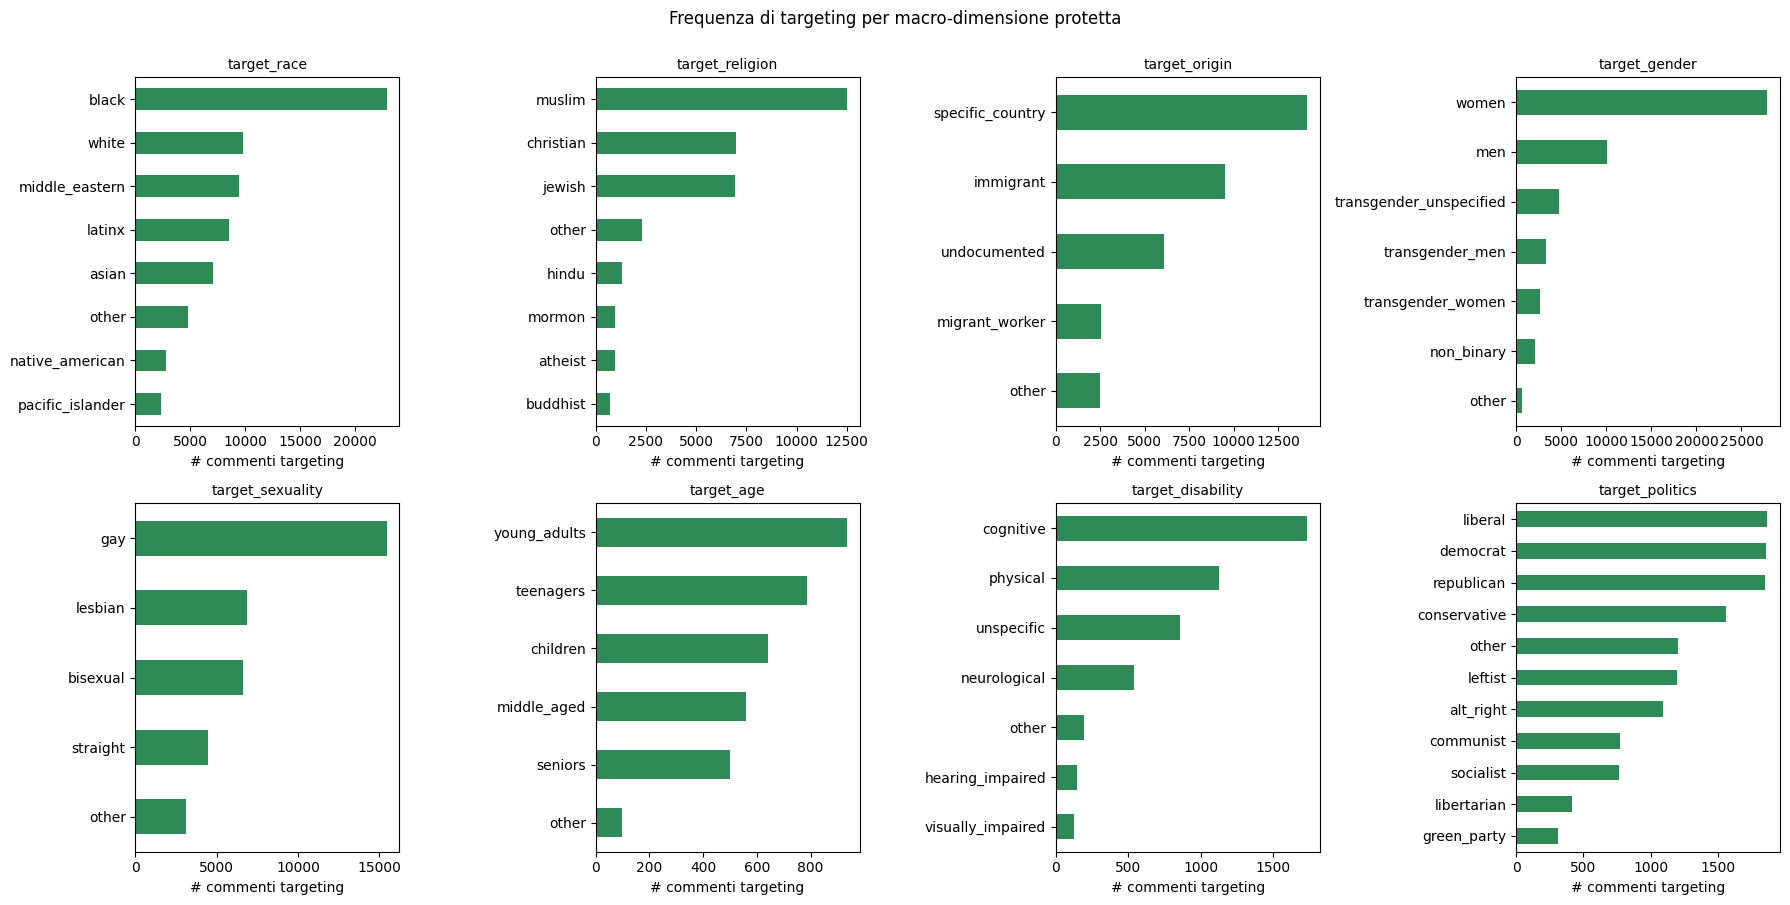

In [32]:
target_dims = [
    "target_race", "target_religion", "target_origin", "target_gender",
    "target_sexuality", "target_age", "target_disability", "target_politics",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, dim in zip(axes.flat, target_dims):
    dummies = [c for c in column_groups["target_groups"] if c.startswith(f"{dim}_")]
    counts = df[dummies].sum().sort_values(ascending=True)
    counts.index = [c.replace(f"{dim}_", "") for c in counts.index]
    counts.plot(kind="barh", ax=ax, color="seagreen")
    ax.set_title(dim, fontsize=10)
    ax.set_xlabel("# commenti targeting")
fig.suptitle("Frequenza di targeting per macro-dimensione protetta", y=1.00)
plt.tight_layout()
plt.show()

### 2.9. - Missing values

Identifichiamo le colonne con valori mancanti non trascurabili (> 1%). Nel dataset Measuring Hate Speech la presenza di `NaN` non è quasi mai "errore di registrazione" ma piuttosto:

- **Opt-out volontario** sull'auto-dichiarazione demografica (es. campi "prefer not to say" o rifiuti nelle survey post-annotazione).
- **Strutturali**: alcune colonne hanno senso solo per sottoinsiemi del corpus.

**Hook etico**: il pattern dei missing è esso stesso un'informazione sensibile. Categorie demografiche su cui gli annotatori rifiutano di rispondere segnalano dimensioni dove la pressione sociale ha condizionato l'auto-rivelazione. Verrà ripreso nel §4 (Privacy) per decidere strategie di imputation o esclusione.

In [33]:
missing = stats["missing_values"]
missing_filtered = {k: v for k, v in missing.items() if v >= 1.0}

if not missing_filtered:
    print("Nessuna colonna con missing >= 1%.")
else:
    missing_series = pd.Series(missing_filtered).sort_values(ascending=False)
    print(f"Colonne con missing >= 1% ({len(missing_series)} su {df.shape[1]}):\n")
    print(missing_series.to_string(float_format=lambda x: f"{x:5.2f}%"))

Nessuna colonna con missing >= 1%.


### 2.10. - Sintesi dell'EDA

Le evidenze raccolte vincolano le scelte etiche dei capitoli successivi:

- **Soggettivita' delle label** (§2.4): con N annotatori per commento, `hate_speech_score` e' una media di giudizi morali — non una verita' oggettiva. Il modello del §5 imparera' a riprodurre il *consenso aggregato di questo specifico pool*, non un concetto universale di hate speech.
- **Composizione per piattaforma** (§2.4-bis): la distribuzione disomogenea tra YouTube, Reddit e Twitter introduce un confounder strutturale. Ogni disparita' apparente per gruppo target nel §3 dovra' essere controllata per la piattaforma di provenienza, pena confondere bias del modello con effetti di norme editoriali differenziate.
- **Soglia di classificazione arbitraria** (§2.5): qualsiasi binarizzazione di `hate_speech_score` e' una decisione di policy, non tecnica. Sara' giustificata esplicitamente nel §5. Il boxplot rende visibile l'asimmetria delle code, decisiva per quantificare il costo di scelte di soglia.
- **Etichette sbilanciate** (§2.6): label come `genocide` o `violence` quasi sempre nulle richiedono metriche robuste (F1, AUC-PR) e attenzione a falsi negativi *catastrofici*.
- **Eterogeneita' del costrutto** (§2.6-bis): la correlazione non uniforme tra le 10 etichette mostra che `hate_speech_score` aggrega dimensioni semanticamente distinte. Vincola il §5 a rendere esplicito, in fase di spiegazione delle predizioni, quale componente dell'hate sta dominando.
- **Bias di campionamento degli annotatori** (§2.7): la composizione del pool determina cosa il dataset chiama "hate". Sbilanciamenti ideologici o demografici sono il vero ground truth del bias di label — focus del §3.
- **Affidabilita' delle annotazioni** (§2.7-bis): la concentrazione della produttivita' (Gini) ridimensiona la nozione di "consenso del pool"; la dispersione intra-commento identifica un sottoinsieme di commenti controversi su cui la performance del modello andra' valutata separatamente al §3.
- **Sbilanciamento dei gruppi target** (§2.8): gruppi sottorappresentati avranno tipicamente recall basso. Driver del fairness audit del §3.
- **Missing demografici** (§2.9): rifiuti di auto-dichiarazione mappano dimensioni sensibili. Vincola le scelte di pseudonimizzazione e generalizzazione nel §4.


## 3. - Fairness

## 4. - Privacy 

## 5. - Implementazione di un modello spiegabile